# Saguaro Images

## look at iNaturalist data

In [15]:
# import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests

In [3]:
# load csv to data frame
df = pd.read_csv('observations-746071.csv')
df.head()

,id,uuid,observed_on,time_observed_at,quality_grade,url,image_url,description,latitude,longitude,positional_accuracy,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id
0,85896,07fe418f-aeac-4e3d-9c16-0dc5c3baf593,2008-05-10,2008-05-10 22:11:00 UTC,research,http://www.inaturalist.org/observations/85896,https://inaturalist-open-data.s3.amazonaws.com...,"<em>Carnegiea gigantea</em>. Soldier Trail, Sa...",32.314691,-110.721311,NaN,Carnegiea gigantea,Carnegiea gigantea,saguaro,Plantae,54449
1,95485,a66827fe-2b26-4e71-b21b-b82f0f1cbef7,2008-05-10,2008-05-10 22:18:50 UTC,research,http://www.inaturalist.org/observations/95485,https://inaturalist-open-data.s3.amazonaws.com...,"<em>Carnegiea gigantea</em>. Soldier Trail, S...",32.314991,-110.720021,NaN,Carnegiea gigantea,Carnegiea gigantea,saguaro,Plantae,54449
2,138529,a158835a-6e98-4a01-8ab1-5fcfb9542692,2012-05-01,NaN,research,http://www.inaturalist.org/observations/138529,https://inaturalist-open-data.s3.amazonaws.com...,NaN,32.434101,-110.908938,4222.0,saguaro cactus,Carnegiea gigantea,saguaro,Plantae,54449
3,465462,f516de81-4690-40a5-bba4-c7d92714d28e,2011-05-18,2011-05-18 19:08:55 UTC,research,http://www.inaturalist.org/observations/465462,https://static.inaturalist.org/photos/587132/m...,"05/18/2011, 2:08 PM\r\nCanon PowerShot SD1400 ...",33.795903,-111.762397,5.0,saguaro,Carnegiea gigantea,saguaro,Plantae,54449
4,704097,357bc12b-c9d7-4618-a566-0924433ce74b,2014-05-28,NaN,research,http://www.inaturalist.org/observations/704097,https://inaturalist-open-data.s3.amazonaws.com...,NaN,33.458443,-111.945152,667.0,saguaro,Carnegiea gigantea,saguaro,Plantae,54449


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11160 entries, 0 to 11159
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   11160 non-null  int64  
 1   uuid                 11160 non-null  str    
 2   observed_on          11160 non-null  str    
 3   time_observed_at     11048 non-null  str    
 4   quality_grade        11160 non-null  str    
 5   url                  11160 non-null  str    
 6   image_url            11160 non-null  str    
 7   description          1081 non-null   str    
 8   latitude             11128 non-null  float64
 9   longitude            11128 non-null  float64
 10  positional_accuracy  8943 non-null   float64
 11  species_guess        11155 non-null  str    
 12  scientific_name      11160 non-null  str    
 13  common_name          11160 non-null  str    
 14  iconic_taxon_name    11160 non-null  str    
 15  taxon_id             11160 non-null  int64  
dt

In [5]:
# get year counts
df['observed_on'] = pd.to_datetime(df['observed_on'])
year_counts = df['observed_on'].dt.year.value_counts().sort_index()
print(year_counts)

observed_on
1978       1
1979       1
1988       1
1996       1
1997       1
1998       2
2000       1
2001       1
2003       4
2004       4
2005       6
2006       9
2007       6
2008      45
2009      17
2010      13
2011      17
2012       8
2013      26
2014      11
2015      17
2016      52
2017    1233
2018     551
2019     192
2020     115
2021     561
2022    1540
2023    1176
2024    1444
2025    3754
2026     350
Name: count, dtype: int64


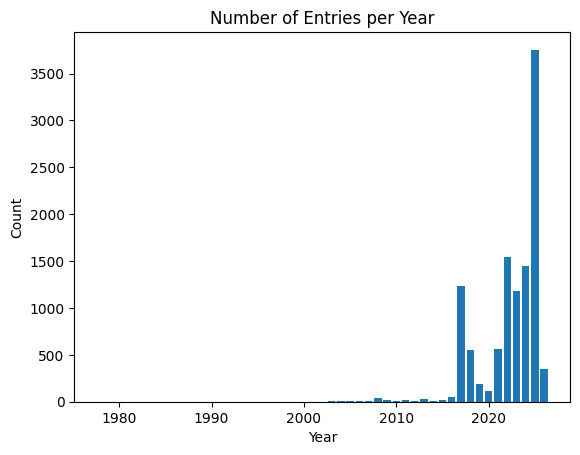

In [6]:
# bar graph by year
plt.bar(year_counts.index, year_counts.values)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Number of Entries per Year")

plt.show()

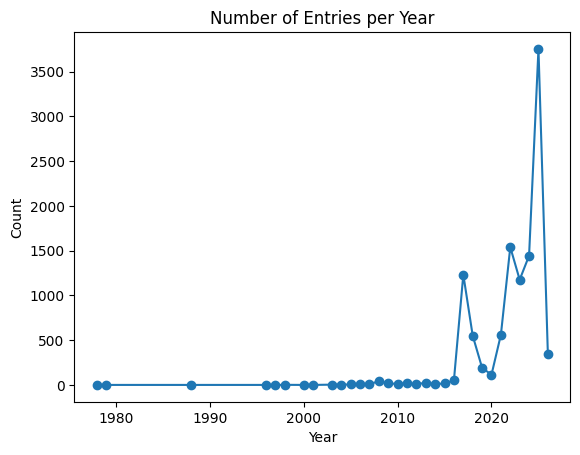

In [7]:
# line graph by year
plt.plot(year_counts.index, year_counts.values, marker='o')

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Number of Entries per Year")

plt.show()

In [8]:
# view images
pd.set_option('display.max_colwidth', None)
df['image_url']

0           https://inaturalist-open-data.s3.amazonaws.com/photos/125677/medium.jpg
1           https://inaturalist-open-data.s3.amazonaws.com/photos/139090/medium.jpg
2           https://inaturalist-open-data.s3.amazonaws.com/photos/192232/medium.jpg
3                           https://static.inaturalist.org/photos/587132/medium.jpg
4           https://inaturalist-open-data.s3.amazonaws.com/photos/882878/medium.JPG
                                            ...                                    
11155    https://inaturalist-open-data.s3.amazonaws.com/photos/671817270/medium.jpg
11156                    https://static.inaturalist.org/photos/672502009/medium.jpg
11157                    https://static.inaturalist.org/photos/672923199/medium.jpg
11158    https://inaturalist-open-data.s3.amazonaws.com/photos/673072197/medium.jpg
11159                    https://static.inaturalist.org/photos/673500412/medium.jpg
Name: image_url, Length: 11160, dtype: str

In [11]:
# remove years with too little
df = df[df['observed_on'].dt.year >= 2016]

In [17]:
# put images into a group
sample = (
    df.groupby(df['observed_on'].dt.year)
      .sample(n=30, random_state=42)
)

In [20]:
# download images
base_folder = "inaturalist_images"

for index, row in sample.iterrows():

    # Get year from date
    year = row['observed_on'].year

    # Create year folder if it doesn't exist
    year_folder = os.path.join(base_folder, str(year))
    os.makedirs(year_folder, exist_ok=True)

    # Image URL
    url = row['image_url']

    # Filename
    filename = f"{index}.jpg"

    # Full path
    filepath = os.path.join(year_folder, filename)

    # Download image
    response = requests.get(url)

    if response.status_code == 200:
        with open(filepath, "wb") as f:
            f.write(response.content)